In [1]:
# Reader setup:
# kaggle competitions download -c google-smartphone-decimeter-challenge -p /path/to/gsdc
# unzip /path/to/gsdc/google-smartphone-decimeter-challenge.zip -d /path/to/gsdc
# Notebook-only extra: python -m pip install matplotlib

from pathlib import Path
import datetime as dt
import math

import matplotlib.pyplot as plt
import numpy as np
import sidereon
import sidereon.data as data

DATA_DIR = Path("/private/tmp/fusion-trial/data/gsdc/2020-05-14-US-MTV-1")
PRODUCT_CACHE = Path("/private/tmp/sid-notebook-cache")
OBS_PATH = DATA_DIR / "Pixel4_GnssLog.20o"
SPAN_PATH = DATA_DIR / "SPAN_Pixel4_10Hz.nmea"

missing = [path for path in (OBS_PATH, SPAN_PATH) if not path.exists()]
if missing:
    missing_names = ", ".join(str(path) for path in missing)
    raise FileNotFoundError(
        f"Missing GSDC drive files: {missing_names}. Point DATA_DIR at the "
        "drive folder containing Pixel4_GnssLog.20o and SPAN_Pixel4_10Hz.nmea."
    )

plt.rcParams.update({"figure.figsize": (7.5, 5.0), "axes.grid": True})
print(f"Using {DATA_DIR}")


Using /private/tmp/fusion-trial/data/gsdc/2020-05-14-US-MTV-1


## Clean up a phone GPS track in five lines

Problem: phone code fixes jump when satellite geometry gets thin. The solver already reports a covariance for each fix; this notebook uses that to lower the weight of loose fixes, then smooths the recorded pass. Data stays outside the repo.

In [2]:
DRIVE_DATE = dt.date(2020, 5, 14)
GPS_MINUS_UTC_S = 18.0


def trim_truncated_final_epoch(text):
    lines = text.splitlines(keepends=True)
    header_end = next(i + 1 for i, line in enumerate(lines) if "END OF HEADER" in line)
    kept = lines[:header_end]
    i = header_end
    dropped = 0
    while i < len(lines):
        line = lines[i]
        if not line.startswith(">"):
            kept.append(line)
            i += 1
            continue
        satellite_count = int(line.split()[8])
        end = i + 1 + satellite_count
        if end <= len(lines):
            kept.extend(lines[i:end])
            i = end
        else:
            dropped = len(lines) - i
            break
    return "".join(kept), dropped


def load_pixel4_rinex(path):
    text = path.read_text()
    try:
        return sidereon.parse_rinex_obs(text), 0
    except sidereon.RinexObsParseError as exc:
        trimmed, dropped = trim_truncated_final_epoch(text)
        print(f"RINEX parser note: {exc}")
        print(f"Dropped {dropped} trailing lines from the incomplete final epoch.")
        return sidereon.parse_rinex_obs(trimmed), dropped


def load_sp3_for_drive(cache_dir):
    cache_dir.mkdir(parents=True, exist_ok=True)
    attempts = []
    for center in ("esa", "gfz", "cod"):
        try:
            product = data.product(center, "sp3", DRIVE_DATE)
            try:
                path = data.fetch(product, cache_dir=str(cache_dir), offline=True)
            except data.OfflineCacheMiss:
                path = data.fetch(
                    product,
                    cache_dir=str(cache_dir),
                    timeout_s=60,
                    retries=2,
                    max_compressed_bytes=128 * 1024 * 1024,
                )
            print(f"SP3 product: {Path(path).name}")
            return sidereon.load_sp3(path), Path(path)
        except Exception as exc:
            attempts.append(f"{center}: {type(exc).__name__}: {exc}")
    raise RuntimeError("Could not load a public SP3 product. " + " | ".join(attempts))


def obs_time_s(epoch):
    return sidereon.j2000_seconds(
        epoch.year, epoch.month, epoch.day, epoch.hour, epoch.minute, epoch.second
    )


def make_spp_config(obs, sp3, epoch_index, initial_guess):
    epoch = obs.epoch(epoch_index).epoch
    ranges = obs.pseudoranges(epoch_index)
    rows = [
        sidereon.SppObservation(sat, float(rng))
        for sat, rng in zip(ranges.satellites, ranges.ranges_m)
        if sat.startswith("G") and sat in sp3.satellites and np.isfinite(rng) and rng > 1e6
    ]
    return sidereon.SppConfig(
        rows,
        obs_time_s(epoch),
        sidereon.second_of_day(epoch.hour, epoch.minute, epoch.second),
        sidereon.day_of_year(epoch.year, epoch.month, epoch.day, epoch.hour, epoch.minute, epoch.second),
        initial_guess,
        sidereon.SppCorrections(ionosphere=False, troposphere=True),
        with_geodetic=True,
    )


def solve_phone_gps_track(obs, sp3, chunk_size=128):
    first_config = make_spp_config(obs, sp3, 0, [0.0, 0.0, 0.0, 0.0])
    first = sidereon.solve_spp(sp3, first_config, coarse_search_seeds=64, max_pdop=999.0)
    guess = [*first.position, first.rx_clock_s]
    configs = [make_spp_config(obs, sp3, i, guess) for i in range(obs.epoch_count)]
    solved = [None] * len(configs)
    failed = []
    for start in range(0, len(configs), chunk_size):
        stop = min(start + chunk_size, len(configs))
        try:
            solved[start:stop] = sidereon.solve_spp_batch(
                sp3, configs[start:stop], parallel=True, max_pdop=999.0
            )
        except sidereon.SolveError:
            for i in range(start, stop):
                try:
                    solved[i] = sidereon.solve_spp(sp3, configs[i], max_pdop=999.0)
                except sidereon.SolveError as exc:
                    failed.append((i, str(exc)))
    keep = np.array([solution is not None for solution in solved], dtype=bool)
    kept = [solution for solution in solved if solution is not None]
    return {
        "times": np.array([obs_time_s(obs.epoch(i).epoch) for i in range(obs.epoch_count) if keep[i]]),
        "positions": np.array([solution.position for solution in kept]),
        "covariances": np.array([solution.position_covariance_ecef_m2 for solution in kept]),
        "covariances_enu": np.array([solution.position_covariance_enu_m2 for solution in kept]),
        "pdop": np.array([solution.dop.pdop for solution in kept]),
        "kept": keep,
        "failed": failed,
    }


def dm_to_deg(value, hemisphere):
    raw = float(value)
    degrees = int(raw // 100)
    out = degrees + (raw - 100 * degrees) / 60.0
    return -out if hemisphere in ("S", "W") else out


def parse_span_gga(path):
    base = dt.datetime(DRIVE_DATE.year, DRIVE_DATE.month, DRIVE_DATE.day)
    rows = []
    for line in path.open():
        if not line.startswith("$GPGGA"):
            continue
        fields = line.split("*", 1)[0].split(",")
        if len(fields) < 12 or not fields[2] or not fields[4] or not fields[9]:
            continue
        utc = base + dt.timedelta(
            hours=int(fields[1][0:2]),
            minutes=int(fields[1][2:4]),
            seconds=float(fields[1][4:]),
        )
        gps = utc + dt.timedelta(seconds=GPS_MINUS_UTC_S)
        rows.append(
            (
                sidereon.j2000_seconds(
                    gps.year,
                    gps.month,
                    gps.day,
                    gps.hour,
                    gps.minute,
                    gps.second + gps.microsecond / 1e6,
                ),
                dm_to_deg(fields[2], fields[3]),
                dm_to_deg(fields[4], fields[5]),
                float(fields[9]) + (float(fields[11]) if fields[11] else 0.0),
            )
        )
    if not rows:
        raise ValueError(f"No GGA rows found in {path}")
    data_rows = np.array(rows, dtype=float)
    xyz_m = sidereon.geodetic_to_ecef(
        np.column_stack([data_rows[:, 1], data_rows[:, 2], data_rows[:, 3] / 1000.0])
    ) * 1000.0
    return data_rows[:, 0], data_rows[:, 1], data_rows[:, 2], data_rows[:, 3], xyz_m


def enu_rotation(lat_deg, lon_deg):
    lat = math.radians(lat_deg)
    lon = math.radians(lon_deg)
    slat, clat = math.sin(lat), math.cos(lat)
    slon, clon = math.sin(lon), math.cos(lon)
    return np.array(
        [[-slon, clon, 0.0], [-slat * clon, -slat * slon, clat], [clat * clon, clat * slon, slat]]
    )


def ecef_to_local(xyz_m, reference_xyz_m, reference_lat_deg, reference_lon_deg):
    return (xyz_m - reference_xyz_m) @ enu_rotation(reference_lat_deg, reference_lon_deg).T


def setup_meter_axes(ax):
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("east (m)")
    ax.set_ylabel("north (m)")
    ax.grid(True, alpha=0.25)


def error_rows(methods, truth_xyz_m, truth_enu_m):
    rows = []
    for name, xyz_m, enu_m in methods:
        horizontal = np.linalg.norm(enu_m[:, :2] - truth_enu_m[:, :2], axis=1)
        total = np.linalg.norm(xyz_m - truth_xyz_m, axis=1)
        vertical = np.abs(enu_m[:, 2] - truth_enu_m[:, 2])
        rows.append(
            {
                "method": name,
                "horizontal_rms_m": math.sqrt(float(np.mean(horizontal * horizontal))),
                "horizontal_max_m": float(np.max(horizontal)),
                "rms_3d_m": math.sqrt(float(np.mean(total * total))),
                "max_3d_m": float(np.max(total)),
                "vertical_rms_m": math.sqrt(float(np.mean(vertical * vertical))),
                "vertical_max_m": float(np.max(vertical)),
            }
        )
    return rows


def print_error_table(rows):
    print("method    h_rms_m  h_max_m  rms_3d_m  max_3d_m  v_rms_m  v_max_m")
    for row in rows:
        print(
            f"{row['method']:<9} "
            f"{row['horizontal_rms_m']:7.2f}  {row['horizontal_max_m']:7.2f}  "
            f"{row['rms_3d_m']:8.2f}  {row['max_3d_m']:8.2f}  "
            f"{row['vertical_rms_m']:7.2f}  {row['vertical_max_m']:7.2f}"
        )


### 1. Raw phone fixes

Parse the phone RINEX, solve GPS-only SPP for each complete epoch, and plot the raw track. The few missing points are epochs that cannot form a GPS-only fix.

RINEX parser note: parse error: RINEX OBS epoch truncated: missing satellite line
Dropped 19 trailing lines from the incomplete final epoch.
SP3 product: ESA0MGNFIN_20201350000_01D_05M_ORB.SP3


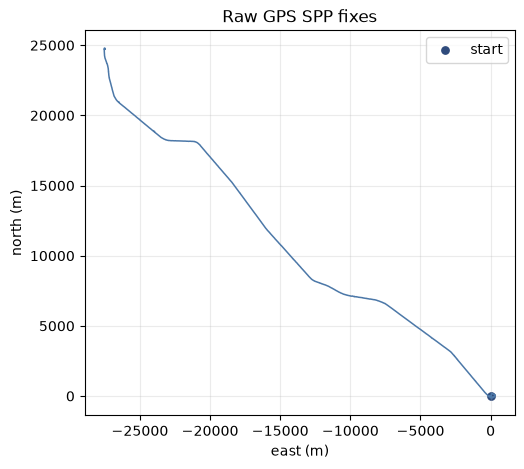

Solved 1731 of 1733 complete RINEX epochs.
Skipped GPS-only epochs: [493, 494]


In [3]:
obs, dropped_lines = load_pixel4_rinex(OBS_PATH)
sp3, sp3_path = load_sp3_for_drive(PRODUCT_CACHE)
track = solve_phone_gps_track(obs, sp3)

times_s = track["times"]
raw_xyz = track["positions"]
raw_cov = track["covariances"]
raw_llh = sidereon.ecef_to_geodetic(raw_xyz / 1000.0)
raw_enu = ecef_to_local(raw_xyz, raw_xyz[0], raw_llh[0, 0], raw_llh[0, 1])
failed_epochs = [index for index, _ in track["failed"]]

fig, ax = plt.subplots()
ax.plot(raw_enu[:, 0], raw_enu[:, 1], color="#4c78a8", linewidth=1.1)
ax.scatter(raw_enu[0, 0], raw_enu[0, 1], s=28, color="#2f4b7c", label="start")
ax.set_title("Raw GPS SPP fixes")
setup_meter_axes(ax)
ax.legend(loc="best")
plt.show()

print(f"Solved {len(raw_xyz)} of {obs.epoch_count} complete RINEX epochs.")
print(f"Skipped GPS-only epochs: {failed_epochs}")


### 2. The covariance warning

The SPP covariance is a per-fix warning label. Larger 3-D sigma marks fixes that should move the track less.

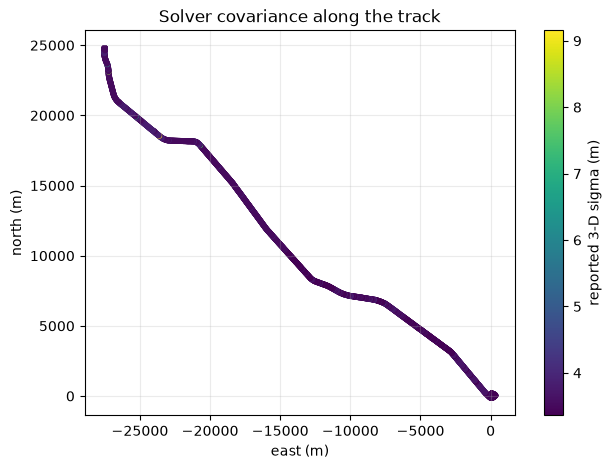

CEP median 1.72 m, CEP max 4.46 m; 3-D sigma max 9.16 m.


In [4]:
sigma_3d_m = np.sqrt(np.trace(track["covariances_enu"], axis1=1, axis2=2))
cep_m = np.array(
    [sidereon.metrics_from_enu_covariance_m2(cov).cep_m.radius_m for cov in track["covariances_enu"]]
)

fig, ax = plt.subplots()
points = ax.scatter(raw_enu[:, 0], raw_enu[:, 1], c=sigma_3d_m, s=11, cmap="viridis")
fig.colorbar(points, ax=ax, label="reported 3-D sigma (m)")
ax.set_title("Solver covariance along the track")
setup_meter_axes(ax)
plt.show()

print(
    f"CEP median {np.median(cep_m):.2f} m, CEP max {np.max(cep_m):.2f} m; "
    f"3-D sigma max {np.max(sigma_3d_m):.2f} m."
)


### 3. TrackFilter in about five lines

Wide covariance tells the filter that a fix is loose, so that fix moves the track less than a tight one.

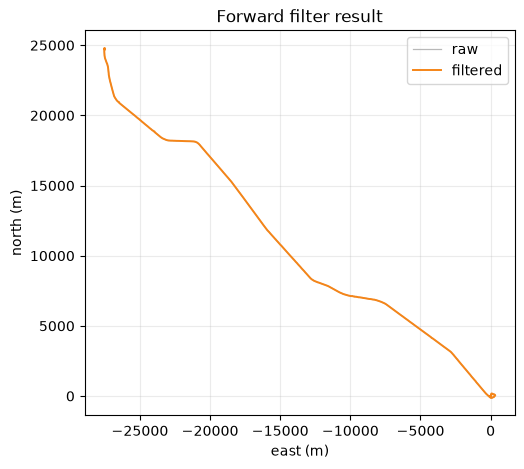

In [5]:
relative_t = times_s - times_s[0]
track_filter = sidereon.TrackFilter.from_position(
    sidereon.TrackCoordinateFrame.ECEF, float(relative_t[0]), raw_xyz[0], raw_cov[0], 100.0, 1.0
)
history = sidereon.TrackRtsHistoryBuilder.from_filter(track_filter)
filtered_xyz = [raw_xyz[0]]
for t_s, fix_xyz, fix_cov in zip(relative_t[1:], raw_xyz[1:], raw_cov[1:]):
    track_filter.predict_recorded(float(t_s - track_filter.state.t_s), history)
    filtered_xyz.append(track_filter.update_position_recorded(fix_xyz, fix_cov, history).updated.position_m.copy())
filtered_xyz = np.asarray(filtered_xyz)
filtered_enu = ecef_to_local(filtered_xyz, raw_xyz[0], raw_llh[0, 0], raw_llh[0, 1])

fig, ax = plt.subplots()
ax.plot(raw_enu[:, 0], raw_enu[:, 1], color="#b8b8b8", linewidth=0.9, label="raw")
ax.plot(filtered_enu[:, 0], filtered_enu[:, 1], color="#f58518", linewidth=1.4, label="filtered")
ax.set_title("Forward filter result")
setup_meter_axes(ax)
ax.legend(loc="best")
plt.show()


### 4. Smooth the recorded pass

The RTS smoother uses the recorded forward pass and revisits earlier fixes after later fixes are known.

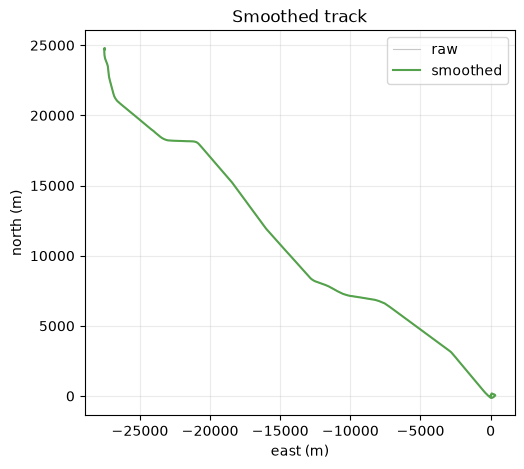

In [6]:
smoothed = sidereon.smooth_track_rts(history.finish())
smoothed_xyz = np.asarray([epoch.state.position_m for epoch in smoothed.epochs])
smoothed_enu = ecef_to_local(smoothed_xyz, raw_xyz[0], raw_llh[0, 0], raw_llh[0, 1])

fig, ax = plt.subplots()
ax.plot(raw_enu[:, 0], raw_enu[:, 1], color="#c7c7c7", linewidth=0.8, label="raw")
ax.plot(smoothed_enu[:, 0], smoothed_enu[:, 1], color="#54a24b", linewidth=1.5, label="smoothed")
ax.set_title("Smoothed track")
setup_meter_axes(ax)
ax.legend(loc="best")
plt.show()


### 5. Check against SPAN truth

SPAN GGA is independent of the phone RINEX. GGA time is UTC, so the parser adds the 18 s GPS-UTC offset before interpolation.

method    h_rms_m  h_max_m  rms_3d_m  max_3d_m  v_rms_m  v_max_m
raw          6.50    40.14      9.33     62.94     6.69    48.48
filtered     5.89    29.78      8.33     40.34     5.90    34.56
smoothed     5.14    15.31      7.04     25.48     4.82    23.82


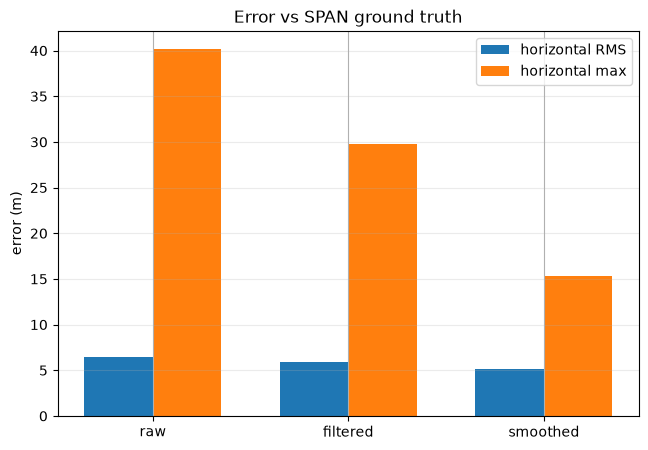

In [7]:
truth_t, truth_lat, truth_lon, truth_h, truth_xyz_samples = parse_span_gga(SPAN_PATH)
truth_xyz = np.column_stack(
    [np.interp(times_s, truth_t, truth_xyz_samples[:, axis]) for axis in range(3)]
)
truth_lat0 = float(np.interp(times_s[0], truth_t, truth_lat))
truth_lon0 = float(np.interp(times_s[0], truth_t, truth_lon))
truth_enu = ecef_to_local(truth_xyz, truth_xyz[0], truth_lat0, truth_lon0)
raw_truth_enu = ecef_to_local(raw_xyz, truth_xyz[0], truth_lat0, truth_lon0)
filtered_truth_enu = ecef_to_local(filtered_xyz, truth_xyz[0], truth_lat0, truth_lon0)
smoothed_truth_enu = ecef_to_local(smoothed_xyz, truth_xyz[0], truth_lat0, truth_lon0)

summary = error_rows(
    [
        ("raw", raw_xyz, raw_truth_enu),
        ("filtered", filtered_xyz, filtered_truth_enu),
        ("smoothed", smoothed_xyz, smoothed_truth_enu),
    ],
    truth_xyz,
    truth_enu,
)
print_error_table(summary)

labels = [row["method"] for row in summary]
x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots()
ax.bar(x - width / 2, [row["horizontal_rms_m"] for row in summary], width, label="horizontal RMS")
ax.bar(x + width / 2, [row["horizontal_max_m"] for row in summary], width, label="horizontal max")
ax.set_xticks(x, labels)
ax.set_ylabel("error (m)")
ax.set_title("Error vs SPAN ground truth")
ax.legend(loc="best")
ax.grid(True, axis="y", alpha=0.25)
plt.show()
